In [2]:
import cv2
import numpy as np
import json
import os
from pathlib import Path

# Пути
data_dir = "../data/my_data/train"
output_dir = "../data/patches"
os.makedirs(f"{output_dir}/occupied", exist_ok=True)
os.makedirs(f"{output_dir}/empty", exist_ok=True)

# Читаем аннотации
with open(f"{data_dir}/_annotations.coco.json") as f:
    coco = json.load(f)

# Маппинг image_id → filename
id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}
id_to_size = {img["id"]: (img["width"], img["height"]) for img in coco["images"]}

# category_id: 1=empty, 2=occupied
patch_count = {"empty": 0, "occupied": 0}

for ann in coco["annotations"]:
    
    cat_id = ann["category_id"]
    if cat_id not in [1, 2]:
        continue

    img_id = ann["image_id"]
    fname = id_to_file[img_id]
    img_path = os.path.join(data_dir, fname)

    img = cv2.imread(img_path)
    if img is None:
        continue

    # Вырезаем bbox
    x, y, bw, bh = [float(v) for v in ann["bbox"]]
    x1, y1 = int(x), int(y)
    x2, y2 = int(x + bw), int(y + bh)

    # Проверяем границы
    h, w = img.shape[:2]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if x2 - x1 < 10 or y2 - y1 < 10:
        continue

    patch = img[y1:y2, x1:x2]
    patch = cv2.resize(patch, (64, 64))  # стандартный размер

    label = "empty" if cat_id == 1 else "occupied"
    save_path = f"{output_dir}/{label}/{img_id}_{ann['id']}.jpg"
    cv2.imwrite(save_path, patch)
    patch_count[label] += 1

print(f"Вырезано патчей:")
print(f"  empty:    {patch_count['empty']}")
print(f"  occupied: {patch_count['occupied']}")

Вырезано патчей:
  empty:    106
  occupied: 130


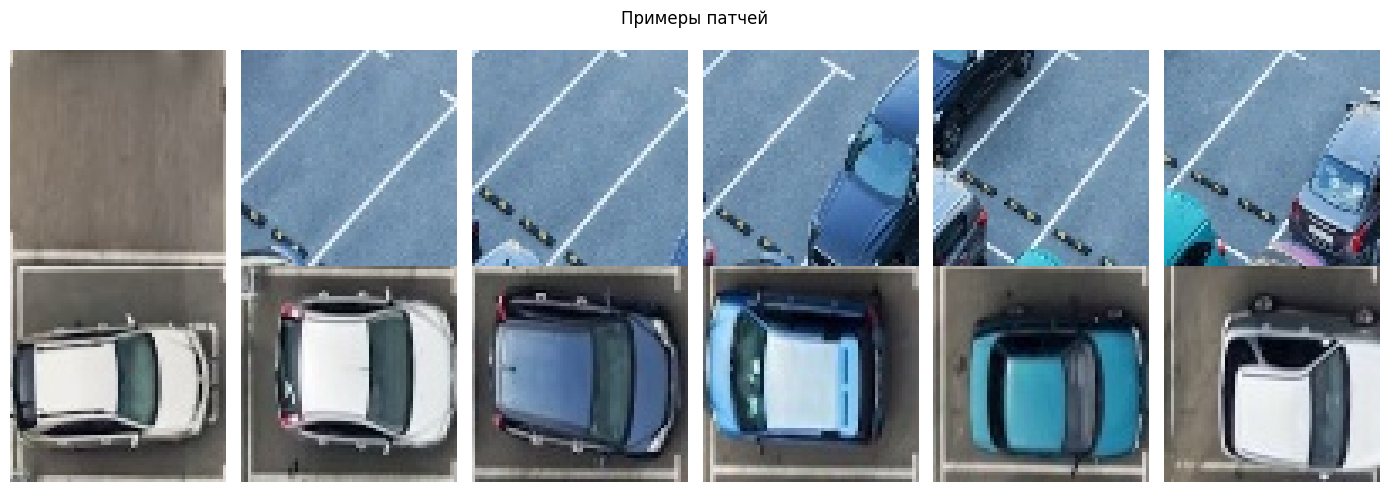

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for i, label in enumerate(["empty", "occupied"]):
    files = os.listdir(f"{output_dir}/{label}")[:6]
    for j, fname in enumerate(files):
        img = cv2.imread(f"{output_dir}/{label}/{fname}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i][j].imshow(img_rgb)
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel(label, fontsize=12)

plt.suptitle("Примеры патчей")
plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import numpy as np

# ─── Датасет ──────────────────────────────────────────────────
class PatchDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        for label, cls in [("empty", 0), ("occupied", 1)]:
            folder = os.path.join(root_dir, label)
            for fname in os.listdir(folder):
                if fname.endswith(".jpg"):
                    self.samples.append((os.path.join(folder, fname), cls))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ─── Трансформации ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ─── Разбиваем на train/val ───────────────────────────────────
full_dataset = PatchDataset(output_dir, transform=train_transform)
val_size = int(len(full_dataset) * 0.2)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train: {train_size} | Val: {val_size}")

# ─── Модель ───────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model_cnn = models.mobilenet_v2(weights="IMAGENET1K_V1")
model_cnn.classifier[1] = nn.Linear(1280, 2)  # 2 класса
model_cnn = model_cnn.to(device)

# ─── Обучение ─────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0
epochs = 30

for epoch in range(epochs):
    # Train
    model_cnn.train()
    train_loss, train_correct = 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Val
    model_cnn.eval()
    val_correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model_cnn(imgs)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / train_size * 100
    val_acc = val_correct / val_size * 100
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_cnn.state_dict(), "../models/cnn_classifier.pth")

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train acc: {train_acc:.1f}% | "
              f"Val acc: {val_acc:.1f}%")

print(f"\n✅ Лучшая val accuracy: {best_val_acc:.1f}%")
print(f"💾 Модель сохранена → ../models/cnn_classifier.pth")

Train: 189 | Val: 47
Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\aktil/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:02<00:00, 5.04MB/s]


Epoch  5/30 | Train acc: 95.8% | Val acc: 95.7%
Epoch 10/30 | Train acc: 98.9% | Val acc: 97.9%
Epoch 15/30 | Train acc: 99.5% | Val acc: 100.0%
Epoch 20/30 | Train acc: 97.9% | Val acc: 100.0%
Epoch 25/30 | Train acc: 100.0% | Val acc: 100.0%
Epoch 30/30 | Train acc: 100.0% | Val acc: 100.0%

✅ Лучшая val accuracy: 100.0%
💾 Модель сохранена → ../models/cnn_classifier.pth
